# Preparation

In [2]:
# Import Basic Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Import Dataset 
df = pd.read_csv("D:\ProjectDS\Californian_Housing_Pred\data\california_housing_train.csv")
df.head()

<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\randi\AppData\Local\Temp\ipykernel_11844\2063899818.py:2: SyntaxWarning: invalid escape sequence '\P'
  df = pd.read_csv("D:\ProjectDS\Californian_Housing_Pred\data\california_housing_train.csv")


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15,5612,1283,1015,472,1.4936,66900
1,-114.47,34.40,19,7650,1901,1129,463,1.8200,80100
2,-114.56,33.69,17,720,174,333,117,1.6509,85700
3,-114.57,33.64,14,1501,337,515,226,3.1917,73400
4,-114.57,33.57,20,1454,326,624,262,1.9250,65500


# Feature Engineering

In [4]:
# Feature Engineering
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
0,-114.31,34.19,15,5612,1283,1015,472,1.4936,66900,11.889831,0.228617,2.150424
1,-114.47,34.40,19,7650,1901,1129,463,1.8200,80100,16.522678,0.248497,2.438445
2,-114.56,33.69,17,720,174,333,117,1.6509,85700,6.153846,0.241667,2.846154
3,-114.57,33.64,14,1501,337,515,226,3.1917,73400,6.641593,0.224517,2.278761
4,-114.57,33.57,20,1454,326,624,262,1.9250,65500,5.549618,0.224209,2.381679


In [5]:
# Saved Feature Engineered Data to CSV
df.to_csv("D:\ProjectDS\Californian_Housing_Pred\data\california_housing_train_fe.csv", index=False)

<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\randi\AppData\Local\Temp\ipykernel_11844\500990957.py:2: SyntaxWarning: invalid escape sequence '\P'
  df.to_csv("D:\ProjectDS\Californian_Housing_Pred\data\california_housing_train_fe.csv", index=False)


## Multicolinearity Check

In [6]:
# Multi-collinearity check by VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant

X_vif = add_constant(df)

vif_df = pd.DataFrame(
    [vif(X_vif.values, i)
     for i in range(X_vif.shape[1])],
    index=X_vif.columns
).reset_index()

vif_df.columns = ['feature', 'vif_score']
vif_df = vif_df.loc[vif_df.feature != 'const']

vif_df

,feature,vif_score
1,longitude,10.680860
2,latitude,11.152850
3,housing_median_age,1.307873
4,total_rooms,18.144262
5,total_bedrooms,49.946434
6,population,7.594558
7,households,46.977367
8,median_income,3.530147
9,median_house_value,2.867888
10,rooms_per_household,1.677286


<Axes: >

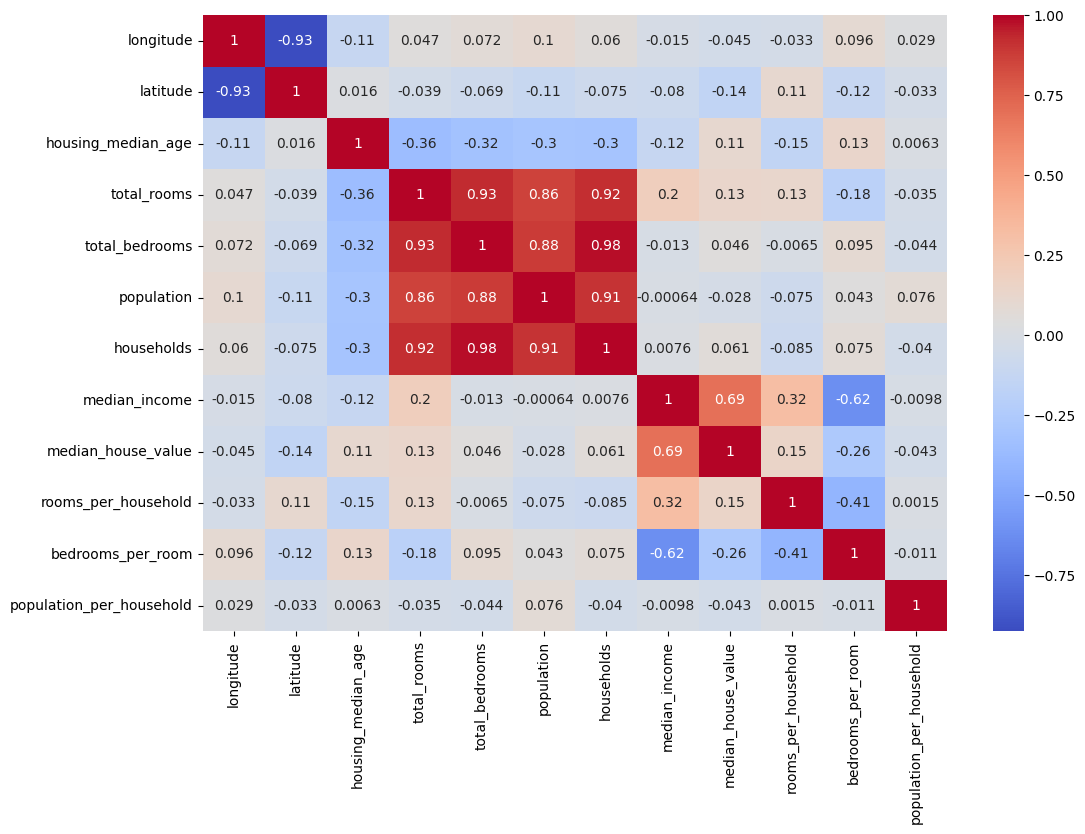

In [7]:
# Multicolinearity Check by Heatmap
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', ax=ax)

In [8]:
# Droping the feature with high VIF score
df.drop(columns=["total_bedrooms", "households", "total_rooms"], inplace=True)
df.tail()

,longitude,latitude,housing_median_age,population,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
16995,-124.26,40.58,52,907,2.3571,111400,6.008130,0.177718,2.457995
16996,-124.27,40.69,36,1194,2.5179,79000,5.051613,0.224777,2.567742
16997,-124.30,41.84,17,1244,3.0313,103600,5.870614,0.198356,2.728070
16998,-124.30,41.80,19,1298,1.9797,85800,5.589958,0.206587,2.715481
16999,-124.35,40.54,52,806,3.0147,94600,6.740741,0.164835,2.985185


In [9]:
# Recheck VIF Score
X_vif = add_constant(df)
vif_df = pd.DataFrame(
    [vif(X_vif.values, i)
     for i in range(X_vif.shape[1])],
    index=X_vif.columns
).reset_index()
vif_df.columns = ['feature', 'vif_score']
vif_df = vif_df.loc[vif_df.feature != 'const']
vif_df

,feature,vif_score
1,longitude,10.436864
2,latitude,10.862695
3,housing_median_age,1.268943
4,population,1.139528
5,median_income,3.361059
6,median_house_value,2.628914
7,rooms_per_household,1.313970
8,bedrooms_per_room,1.971115
9,population_per_household,1.012481


<Axes: >

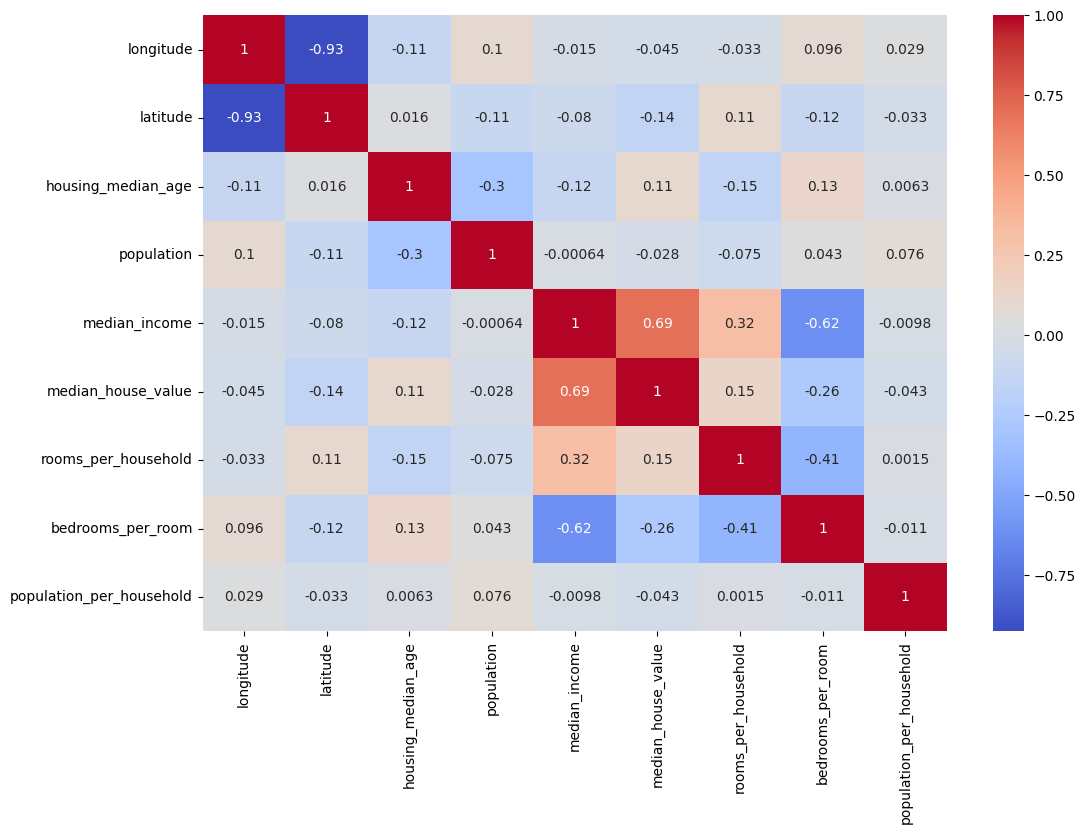

In [10]:

# Recheck Multicolinearity by Heatmap
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', ax=ax)

In [11]:
# Export to CSV
df.to_csv("D:\ProjectDS\Californian_Housing_Pred\data\california_housing_train_fe_drop_multico.csv", index=False)

<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\randi\AppData\Local\Temp\ipykernel_11844\2560074547.py:2: SyntaxWarning: invalid escape sequence '\P'
  df.to_csv("D:\ProjectDS\Californian_Housing_Pred\data\california_housing_train_fe_drop_multico.csv", index=False)
